In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Concatenate, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [7]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow version:", tf.__version__)
print("GPU Device:", tf.test.gpu_device_name())

Num GPUs Available:  1
TensorFlow version: 2.10.1
GPU Device: /device:GPU:0


In [8]:
# PARAMETERS
data_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\train_feature_combined_emotion_dataset.csv"
test_dataset_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\test_dataset.csv"
glove_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\glove.6B.300d.txt"
max_words = 10000
max_len = 100
embedding_dim = 300

In [9]:
df = pd.read_csv(data_path)


In [10]:
# Create target label by taking argmax across emotion columns
emotion_cols = ['happiness', 'sadness', 'disgust', 'anger', 'fear', 'surprise', 'neutral']
df['label'] = df[emotion_cols].values.argmax(axis=1)
num_classes = len(emotion_cols)
y = to_categorical(df['label'], num_classes=num_classes)

In [11]:
# Prepare sentiment features and normalize
sentiment_features = df[['TextBlob_Polarity', 'VADER_Compound']].values
scaler = StandardScaler()
sentiment_features = scaler.fit_transform(sentiment_features)


In [12]:
# TOKENIZE TEXT
df['text'] = df['text'].astype(str)
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['text'])
sequences = tokenizer.texts_to_sequences(df['text'])
X_text = pad_sequences(sequences, maxlen=max_len)

In [13]:
# SPLIT DATA (80% train, 20% val)
X_text_train, X_text_val, X_sent_train, X_sent_val, y_train, y_val = train_test_split(
    X_text, sentiment_features, y, test_size=0.20, random_state=42, stratify=y)

In [14]:
# LOAD PRETRAINED GLOVE EMBEDDINGS
embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coeffs
print(f'Found {len(embeddings_index)} word vectors in GloVe.')

Found 400000 word vectors in GloVe.


In [15]:
# CREATE EMBEDDING MATRIX
word_index = tokenizer.word_index
num_words = min(max_words, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i >= max_words:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [16]:
# DEFINE MODEL ARCHITECTURE
# Text branch
text_input = Input(shape=(max_len,), name='text_input')
embedding_layer = Embedding(input_dim=num_words,
                           output_dim=embedding_dim,
                           weights=[embedding_matrix],
                           input_length=max_len,
                           trainable=False)(text_input)

# LSTM layer optimized for GPU
lstm_out = Bidirectional(LSTM(128, 
                             dropout=0.2,
                             # Remove recurrent_dropout for cuDNN compatibility
                             return_sequences=False,
                             unroll=False,  # Keep False for GPU
                             use_bias=True))(embedding_layer)

# Add a dense layer after LSTM to create text features
text_features = Dense(128, activation='relu', name='text_features')(lstm_out)
text_features = Dropout(0.3)(text_features)

# Sentiment branch
sent_input = Input(shape=(sentiment_features.shape[1],), name='sentiment_input')
sent_dense = Dense(32, activation='relu')(sent_input)
sent_dense = Dropout(0.3)(sent_dense)

# Combine branches
combined = Concatenate()([text_features, sent_dense])
combined_dense = Dense(64, activation='relu', name='combined_dense')(combined)
combined_dense = Dropout(0.5)(combined_dense)
output = Dense(num_classes, activation='softmax', name='output')(combined_dense)

# Build and compile the full model (with sentiment features)
lstm_model = Model(inputs=[text_input, sent_input], outputs=output)
lstm_model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

lstm_model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text_input (InputLayer)        [(None, 100)]        0           []                               
                                                                                                  
 embedding (Embedding)          (None, 100, 300)     3000000     ['text_input[0][0]']             
                                                                                                  
 bidirectional (Bidirectional)  (None, 256)          439296      ['embedding[0][0]']              
                                                                                                  
 sentiment_input (InputLayer)   [(None, 2)]          0           []                               
                                                                                              

In [17]:
# DEFINE CALLBACKS
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint(filepath='best_lstm_model.h5', monitor='val_loss', save_best_only=True)
]


In [18]:
# TRAIN THE LSTM MODEL
history_lstm = lstm_model.fit(
    {'text_input': X_text_train, 'sentiment_input': X_sent_train},
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=({'text_input': X_text_val, 'sentiment_input': X_sent_val}, y_val),
    callbacks=callbacks
)

Epoch 1/50
15309/15309 [==============================] - 426s 27ms/step - loss: 0.5715 - accuracy: 0.7867 - val_loss: 0.4518 - val_accuracy: 0.8200
Epoch 2/50
15309/15309 [==============================] - 352s 23ms/step - loss: 0.4677 - accuracy: 0.8169 - val_loss: 0.4365 - val_accuracy: 0.8257
Epoch 3/50
15309/15309 [==============================] - 354s 23ms/step - loss: 0.4540 - accuracy: 0.8209 - val_loss: 0.4321 - val_accuracy: 0.8269
Epoch 4/50
15309/15309 [==============================] - 397s 26ms/step - loss: 0.4478 - accuracy: 0.8231 - val_loss: 0.4285 - val_accuracy: 0.8279
Epoch 5/50
15309/15309 [==============================] - 520s 34ms/step - loss: 0.4420 - accuracy: 0.8245 - val_loss: 0.4290 - val_accuracy: 0.8278
Epoch 6/50
15309/15309 [==============================] - 446s 29ms/step - loss: 0.4394 - accuracy: 0.8253 - val_loss: 0.4300 - val_accuracy: 0.8279
Epoch 7/50
15309/15309 [==============================] - 442s 29ms/step - loss: 0.4365 - accuracy: 0.8267

In [ ]:
lstm_model.save('LSTM_9.h5')


In [19]:
test_df = pd.read_csv(test_dataset_path)


In [20]:
# Create target labels for test data
test_df['label'] = test_df[emotion_cols].values.argmax(axis=1)
y_test = to_categorical(test_df['label'], num_classes=num_classes)

In [21]:
# Tokenize and pad the test text data
test_df['text'] = test_df['text'].astype(str)
test_sequences = tokenizer.texts_to_sequences(test_df['text'])
X_text_test = pad_sequences(test_sequences, maxlen=max_len)

In [22]:
# Prepare sentiment features for test data using the same scaler
test_sentiment_features = test_df[['TextBlob_Polarity', 'VADER_Compound']].values
test_sentiment_features = scaler.transform(test_sentiment_features)  # Use transform, not fit_transform

In [25]:
# EVALUATE ON TEST SET
print("\n--- Evaluating on Test Set ---")
loss_lstm, acc_lstm = lstm_model.evaluate(
    {'text_input': X_text_test, 'sentiment_input': test_sentiment_features}, 
    y_test
)
print(f'LSTM Test Loss: {loss_lstm:.4f} / Test Accuracy: {acc_lstm:.4f}')


--- Evaluating on Test Set ---
99/99 [==============================] - 1s 10ms/step - loss: 1.1670 - accuracy: 0.6302
LSTM Test Loss: 1.1670 / Test Accuracy: 0.6302


In [26]:
# Get predictions and true labels
y_pred_lstm = lstm_model.predict({'text_input': X_text_test, 'sentiment_input': test_sentiment_features})
y_pred_lstm_classes = np.argmax(y_pred_lstm, axis=1)
y_true = np.argmax(y_test, axis=1)

99/99 [==============================] - 1s 11ms/step


In [27]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred_lstm_classes)
precision = precision_score(y_true, y_pred_lstm_classes, average='weighted')
recall = recall_score(y_true, y_pred_lstm_classes, average='weighted')
f1 = f1_score(y_true, y_pred_lstm_classes, average='weighted')

c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
# Print overall metrics
print("\nOverall Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Overall Metrics:
Accuracy: 0.6302
Precision: 0.6238
Recall: 0.6302
F1 Score: 0.5779


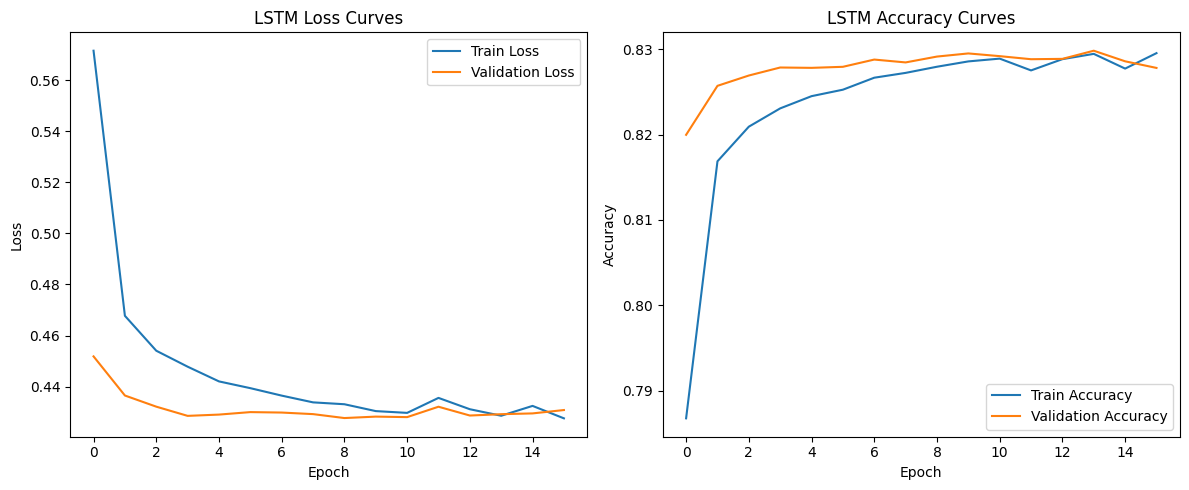

In [29]:
# Learning Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('LSTM_9_learning_curves.png')
plt.show()

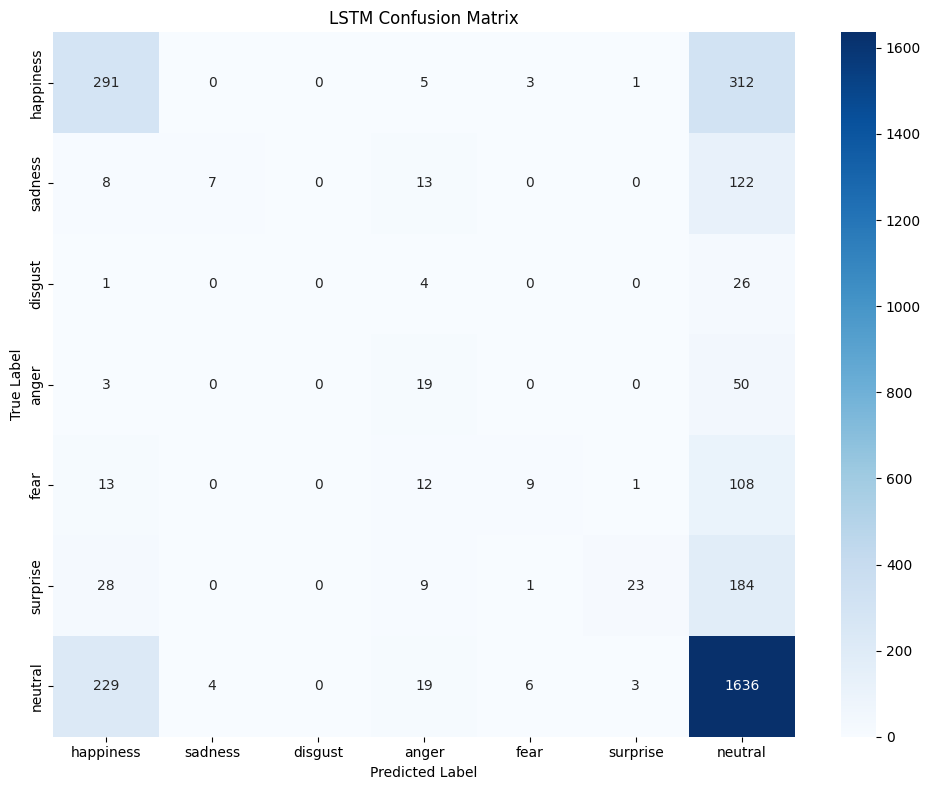

In [30]:

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_lstm_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=emotion_cols, yticklabels=emotion_cols)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('LSTM Confusion Matrix')
plt.tight_layout()
plt.show()

In [31]:
# Classification Report
print("\nLSTM Classification Report:")
report = classification_report(y_true, y_pred_lstm_classes, target_names=emotion_cols, output_dict=True)
print(classification_report(y_true, y_pred_lstm_classes, target_names=emotion_cols))


LSTM Classification Report:
              precision    recall  f1-score   support

   happiness       0.51      0.48      0.49       612
     sadness       0.64      0.05      0.09       150
     disgust       0.00      0.00      0.00        31
       anger       0.23      0.26      0.25        72
        fear       0.47      0.06      0.11       143
    surprise       0.82      0.09      0.17       245
     neutral       0.67      0.86      0.75      1897

    accuracy                           0.63      3150
   macro avg       0.48      0.26      0.27      3150
weighted avg       0.62      0.63      0.58      3150



c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ronl

<Figure size 1200x600 with 0 Axes>

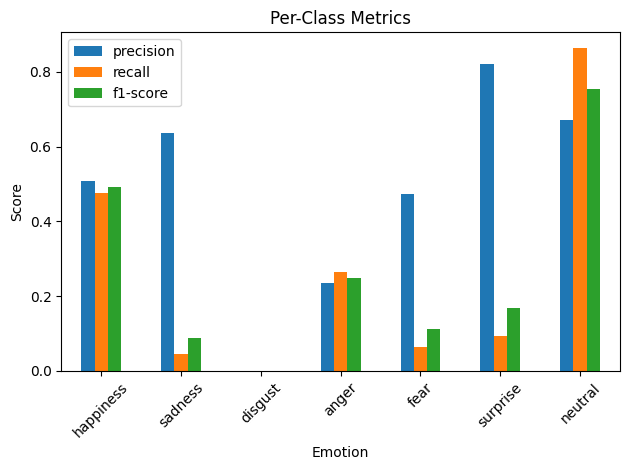

In [32]:
# 4. Per-class metrics visualization
plt.figure(figsize=(12, 6))
metrics_df = pd.DataFrame(report).transpose()
metrics_df = metrics_df.iloc[:-3]  # Remove avg rows
metrics_df = metrics_df[['precision', 'recall', 'f1-score']]
metrics_df.plot(kind='bar')
plt.title('Per-Class Metrics')
plt.ylabel('Score')
plt.xlabel('Emotion')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

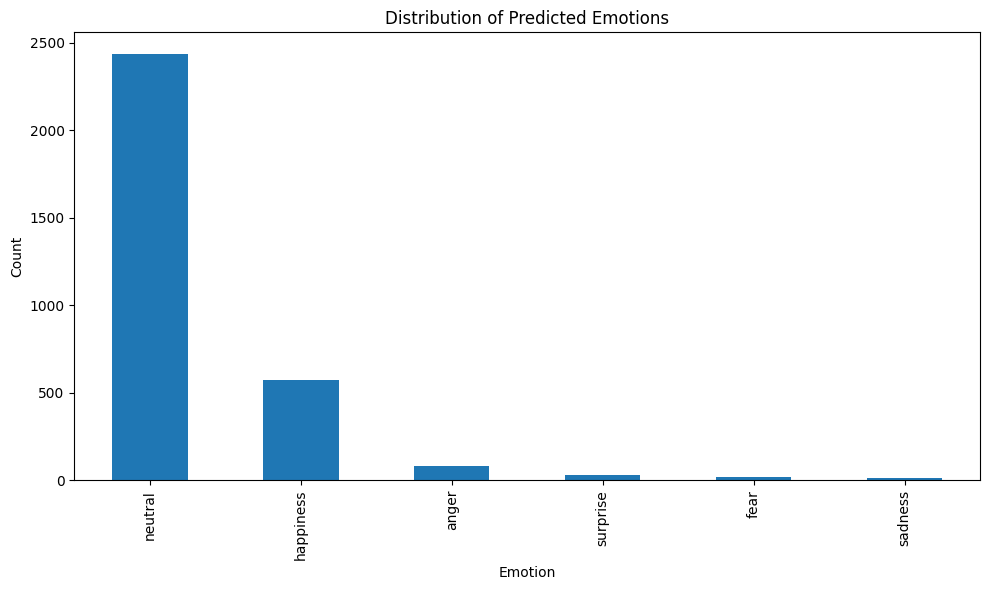

In [33]:
# 6. Additional: Prediction distribution
plt.figure(figsize=(10, 6))
pd.Series(y_pred_lstm_classes).map(dict(enumerate(emotion_cols))).value_counts().plot(kind='bar')
plt.title('Distribution of Predicted Emotions')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

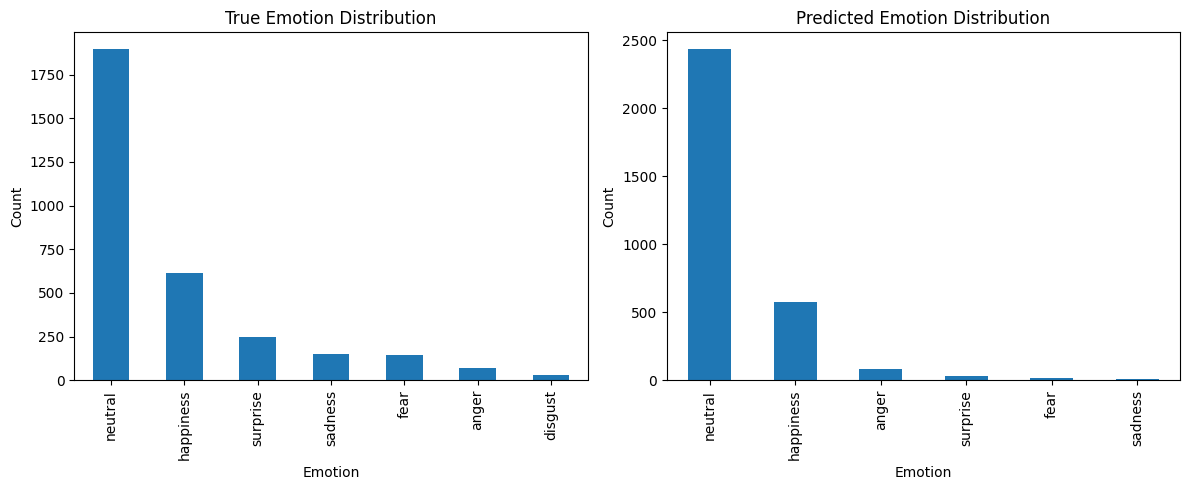

In [35]:
# 7. Compare with true distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
pd.Series(y_true).map(dict(enumerate(emotion_cols))).value_counts().plot(kind='bar')
plt.title('True Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
pd.Series(y_pred_lstm_classes).map(dict(enumerate(emotion_cols))).value_counts().plot(kind='bar')
plt.title('Predicted Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.tight_layout()
plt.show()